# Value at Risk and Expected Shortfall

**Value at Risk (VaR)** answers a simple question: *"Over a given horizon, how bad can losses get at a given confidence level?"* A 1-day 99% VaR of \$281k means on 99% of days losses stay below \$281k; on the worst 1% they may exceed it.

However, VaR says nothing about *how much worse* than VaR losses can be. **Expected Shortfall (ES)** fills the gap by averaging the losses in the tail beyond VaR. 

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

import seaborn as sns
sns.set_style('whitegrid')

np.random.seed(42)

In [2]:
# We will calculate the 1-day 99% VaR and ES of a portfolio worth $10m consisting of investments in four stock indices as in John Hull's textbook
tickers = ['^GSPC', '^FTSE', '^FCHI', '^N225'] # S&P 500 (USA), FTSE 100 (UK), CAC 40 (France), Nikkei 225 (Japan)
weights = np.array([0.25, 0.25, 0.25, 0.25]) # assume it is an equally weighted portfolio
portfolio_value = 10_000_000
confidence_level = 0.99 
time_horizon = 1

# Get the data
start_date = '2020-01-01'
end_date = '2025-12-31'
print(f"Downloading data for {tickers}...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']
data = data.ffill() # replace missing data (e.g. due to holidays) with the last valid observation forward (ffill)

log_returns = np.log(data / data.shift(1)).dropna()
log_returns.columns = ['S&P 500', 'FTSE 100', 'CAC 40', 'Nikkei 225']

print(f"\nData shape: {log_returns.shape}")
print(f"Date range: {log_returns.index[0]} to {log_returns.index[-1]}")
print(f"\nReturn statistics:")
print(log_returns.describe())


Data shape: (1558, 4)
Date range: 2020-01-07 00:00:00 to 2025-12-30 00:00:00

Return statistics:
           S&P 500     FTSE 100       CAC 40   Nikkei 225
count  1558.000000  1558.000000  1558.000000  1558.000000
mean      0.000197     0.000174     0.000484     0.000497
std       0.012411     0.010374     0.013000     0.013529
min      -0.130983    -0.115117    -0.127652    -0.132341
25%      -0.005061    -0.003793    -0.004589    -0.006026
50%       0.000575     0.000493     0.000624     0.000002
75%       0.006397     0.004879     0.006473     0.007281
max       0.080561     0.086664     0.090895     0.097366


## Method 1: Historical simulation

This is a **non-parametric** approach: it makes *no distributional assumption* and simply uses the empirical distribution of past portfolio returns. We sort the historical returns, and read off the loss at the $(1-\alpha)$ quantile; ES is the average of everything below it.

**Pros:** captures the true fat tails and correlations actually observed (the 2020 COVID crash is in this window). **Cons:** entirely backward-looking; it can only produce losses of a magnitude that has already happened, and weights a 5-year-old crisis the same as yesterday.

In [3]:
# Historical simulation method
portfolio_returns = log_returns.dot(weights) # matrix multiplication
sorted_returns = portfolio_returns.sort_values(ascending=True) # sort returns from lowest (worst loss) to highest
cutoff_time_index = int((1 - confidence_level) * len(sorted_returns)) # the bottom 1% of returns

# VaR is the return at the cutoff index
var_percent = -sorted_returns.iloc[cutoff_time_index]
var_dollar = portfolio_value * var_percent * np.sqrt(time_horizon)

# ES is the average of all returns worse than the VaR
es_percent = -sorted_returns.iloc[:cutoff_time_index].mean()
es_dollar = portfolio_value * es_percent * np.sqrt(time_horizon)

print(f"--- Historical Method  ---")
print(f"VaR: ${var_dollar:,.2f}")
print(f"ES:  ${es_dollar:,.2f}")

--- Historical Method  ---
VaR: $281,187.96
ES:  $464,082.69


## Method 2: Parametric (variance-covariance)

Assume portfolio returns are **normally distributed** with moments obtained from the covariance matrix:

$$\mu_p = w^{\top}\mu, \qquad \sigma_p = \sqrt{w^{\top}\Sigma\,w}.$$

Then VaR and ES have closed forms: with $z_{1-\alpha} = \Phi^{-1}(1-\alpha)$ (e.g. $\Phi^{-1}(0.01) \approx -2.326$) and $\varphi$ the normal density,

$$\text{VaR}_\alpha = -\big(\mu_p + z_{1-\alpha}\,\sigma_p\big), \qquad \text{ES}_\alpha = -\left(\mu_p - \sigma_p\,\frac{\varphi(z_{1-\alpha})}{1-\alpha}\right).$$

This method is fast and analytic, but the normality assumption **understates tail risk** since real returns are fat-tailed. The backtest below shows exactly this failure.

In [4]:
# Parametric method (variance-covariance matrix)
# This method assumes returns are normally distributed

cov_matrix = log_returns.cov()
avg_return = log_returns.mean().dot(weights)
    
# Calculate the portfolio volatility sqrt(w.T * Cov * w)
portfolio_std = np.sqrt(weights.T.dot(cov_matrix).dot(weights))
    
# Calculate z-score
z_score = norm.ppf(1 - confidence_level) # ppf is the quantile function; it returns a standard deviation multiplier for what value that percentage occurs at, e.g. around 2.326 in the current example

var_percent_1 = -(avg_return + z_score * portfolio_std)
var_dollar_1 = portfolio_value * var_percent_1 * np.sqrt(time_horizon)

# ES closed formula = mu + sigma * (pdf(ppf(alpha)) / (1-alpha))
es_percent_1 = -(avg_return - portfolio_std * (norm.pdf(z_score) / (1 - confidence_level)))
es_dollar_1 = portfolio_value * es_percent_1 * np.sqrt(time_horizon)

print(f"--- Parametric Method ---")
print(f"VaR: ${var_dollar_1:,.2f}")
print(f"ES:  ${es_dollar_1:,.2f}")

--- Parametric Method ---
VaR: $215,363.26
ES:  $247,226.26


## Method 3: Monte Carlo simulation

Rather than using an analytic formula, we **simulate** many one-day portfolio returns from a multivariate normal calibrated to the sample mean vector and covariance matrix. Correlation is imposed via the **Cholesky decomposition** $\Sigma = LL^{\top}$: if $Z$ are independent standard normals, then $\mu + LZ$ has the target covariance. VaR and ES are then read off the empirical quantile of the simulated returns, exactly as in the historical method. Under a Gaussian assumption this converges to the parametric answer, but the framework is more **flexible**.

In [5]:
# Monte Carlo simulation
simulations = 10000

mean_returns = log_returns.mean().values
cov_matrix = log_returns.cov().values

# Cholesky decomposition: L is a lower triangular matrix such that L * L.T = Covariance Matrix
L = np.linalg.cholesky(cov_matrix)

uncorrelated_randoms = np.random.normal(0, 1, (len(weights), simulations)) # uncorrelated random variables (standard normal)
correlated_returns = mean_returns[:, np.newaxis] + np.dot(L, uncorrelated_randoms) # correlated returns = mean + L * uncorrelated randoms
simulated_portfolio_returns = np.dot(weights, correlated_returns)
sorted_sim_returns = np.sort(simulated_portfolio_returns)
cutoff_index = int((1 - confidence_level) * simulations)

var_percent_2 = -sorted_sim_returns[cutoff_index]
var_dollar_2 = portfolio_value * var_percent_2 * np.sqrt(time_horizon)

es_percent_2 = -sorted_sim_returns[:cutoff_index].mean()
es_dollar_2 = portfolio_value * es_percent_2 * np.sqrt(time_horizon)

print(f"--- Monte Carlo Method ({simulations} Simulations) ---")
print(f"VaR: ${var_dollar_2:,.2f}")
print(f"ES:  ${es_dollar_2:,.2f}")

--- Monte Carlo Method (10000 Simulations) ---
VaR: $221,811.21
ES:  $255,639.14


## Comparing the three methods

In [6]:
# Compare the methods
comparison = pd.DataFrame({
    'Method': ['Historical', 'Parametric', 'Monte Carlo'],
    'VaR ($)': [var_dollar, var_dollar_1, var_dollar_2],
    'ES ($)': [es_dollar, es_dollar_1, es_dollar_2]
})

print(comparison.to_string(index=False))
print("\nObservations:")
print("• Historical VaR is higher (includes 2020 COVID crash)")
print("• Parametric/MC VaR assume normality (miss fat tails)")
print("• ES always exceeds VaR (measures tail risk)")

     Method       VaR ($)        ES ($)
 Historical 281187.962639 464082.685225
 Parametric 215363.259975 247226.261898
Monte Carlo 221811.208274 255639.138186

Observations:
• Historical VaR is higher (includes 2020 COVID crash)
• Parametric/MC VaR assume normality (miss fat tails)
• ES always exceeds VaR (measures tail risk)


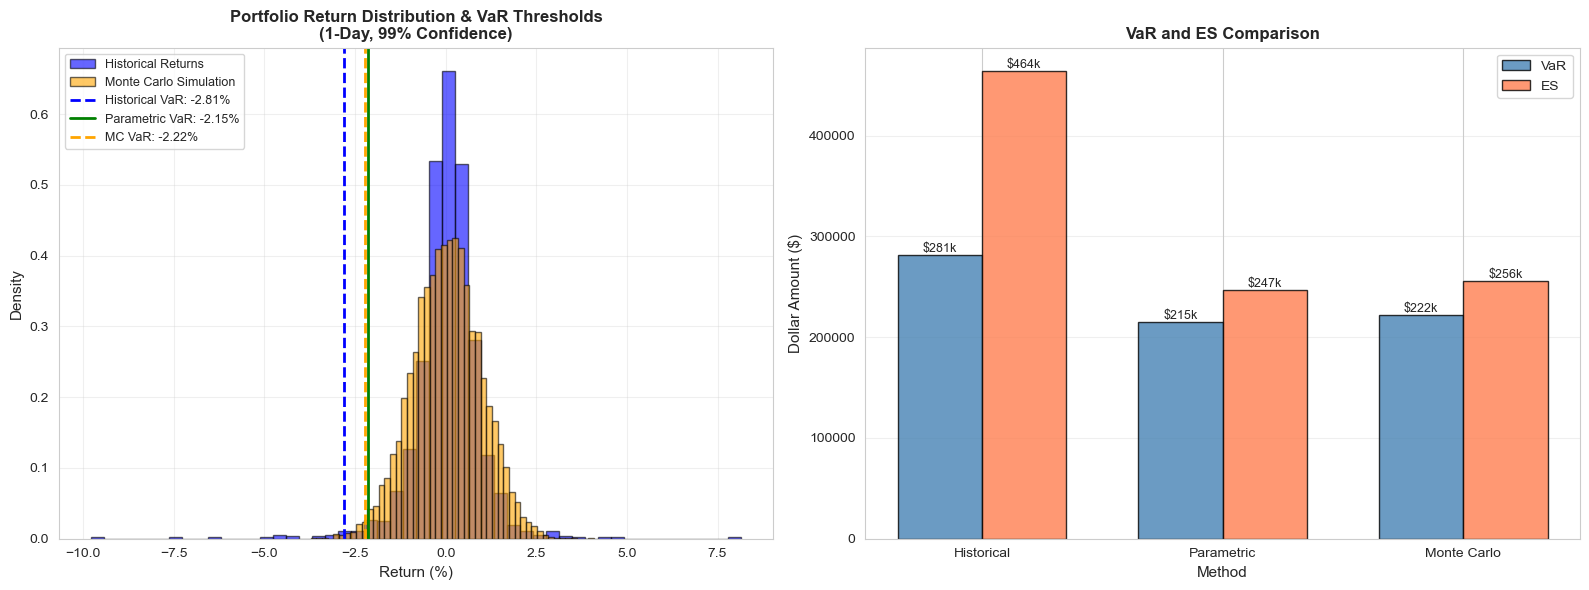

In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Return distributions
ax1 = axes[0]
ax1.hist(sorted_returns*100, bins=50, alpha=0.6, density=True,  # Plot historical return distribution
         label='Historical Returns', color='blue', edgecolor='black')
ax1.hist(sorted_sim_returns*100, bins=50, alpha=0.6, density=True, # Plot Monte Carlo simulated return distribution
         label='Monte Carlo Simulation', color='orange', edgecolor='black')

# VaR lines
ax1.axvline(-var_percent*100, color='blue', linestyle='--', linewidth=2, 
            label=f'Historical VaR: {-var_percent*100:.2f}%')
ax1.axvline(-var_percent_1*100, color='green', linestyle='-', linewidth=2, 
            label=f'Parametric VaR: {-var_percent_1*100:.2f}%')
ax1.axvline(-var_percent_2*100, color='orange', linestyle='--', linewidth=2, 
            label=f'MC VaR: {-var_percent_2*100:.2f}%')

ax1.set_title(f'Portfolio Return Distribution & VaR Thresholds\n({time_horizon}-Day, {confidence_level*100:.0f}% Confidence)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Return (%)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: VaR comparison bar chart
ax2 = axes[1]
x = np.arange(len(comparison))
width = 0.35

bars1 = ax2.bar(x - width/2, comparison['VaR ($)'], width, 
                label='VaR', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x + width/2, comparison['ES ($)'], width, 
                label='ES', color='coral', alpha=0.8, edgecolor='black')

ax2.set_title('VaR and ES Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('Method', fontsize=11)
ax2.set_ylabel('Dollar Amount ($)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison['Method'])
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'${height/1000:.0f}k',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Backtesting the VaR model

In backtesting we count **violations** (days where the actual loss exceeded the predicted VaR). At the 99% level we expect a violation rate of $1-\alpha = 1\%$, i.e. $(1-\alpha)\,N \approx 15.6$ breaches over $N=1558$ days.

In [8]:
# Backtest VaR model
portfolio_losses = -portfolio_returns * portfolio_value
violations_hist = (portfolio_losses > var_dollar).sum()
violations_param = (portfolio_losses > var_dollar_1).sum()

expected_violations = (1 - confidence_level) * len(portfolio_losses)
violation_rate_hist = violations_hist / len(portfolio_losses)
violation_rate_param = violations_param / len(portfolio_losses)

print("--- VaR Backtesting Results ---")
print(f"Total observations: {len(portfolio_losses)}")
print(f"Expected violations: {expected_violations:.2f} ({(1-confidence_level)*100:.2f}%)")
print(f"\nHistorical VaR:")
print(f"  Actual violations: {violations_hist} ({violation_rate_hist*100:.2f}%)")
print(f"  Status: {'PASS' if abs(violation_rate_hist - (1-confidence_level)) < 0.005 else 'REVIEW'}")
print(f"\nParametric VaR:")
print(f"  Actual violations: {violations_param} ({violation_rate_param*100:.2f}%)")
print(f"  Status: {'PASS' if abs(violation_rate_param - (1-confidence_level)) < 0.005 else 'REVIEW'}")

--- VaR Backtesting Results ---
Total observations: 1558
Expected violations: 15.58 (1.00%)

Historical VaR:
  Actual violations: 15 (0.96%)
  Status: PASS

Parametric VaR:
  Actual violations: 28 (1.80%)
  Status: REVIEW


# Part II: VaR of an Options Portfolio

In this part, we will
1. Build a multi-leg S&P 500 options book (spreads, protective puts, a calendar spread) and price every leg with Black–Scholes.
2. Aggregate the book's Greeks to see its net exposures.
3. Simulate the underlying one day forward, reprice every option under each scenario, and build the empirical P&L distribution from which VaR and ES follow directly.

In [9]:
def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    """
    Calculate Black-Scholes option price.
    
    Parameters:
    S: Current stock price
    K: Strike price
    T: Time to maturity (years)
    r: Risk-free rate
    sigma: Volatility
    option_type: 'call' or 'put'
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

def calculate_greeks(S, K, T, r, sigma, option_type='call'):
    """
    Calculate option Greeks.
    
    Returns:
    Dictionary with Delta, Gamma, Vega, Theta, Rho
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Delta
    if option_type == 'call':
        delta = norm.cdf(d1)
    else:
        delta = -norm.cdf(-d1)
    
    # Gamma (same for calls and puts)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    # Vega (same for calls and puts)
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100  # divided by 100 for 1% change
    
    # Theta
    if option_type == 'call':
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        theta = (-S * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
    
    # Rho
    if option_type == 'call':
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    
    return {
        'Delta': delta,
        'Gamma': gamma,
        'Vega': vega,
        'Theta': theta,
        'Rho': rho
    }

print("Black-Scholes pricing and Greeks functions defined.")

Black-Scholes pricing and Greeks functions defined.


In [10]:
# Create a sample options portfolio
# Assume we have positions in options on the S&P 500 index
S0 = 6000  # Current S&P 500 level
r = 0.04   # Risk-free rate
sigma = 0.18  # Implied volatility

# Portfolio: mix of calls and puts at different strikes and maturities
portfolio = pd.DataFrame([
    # Long call spread
    {'Type': 'call', 'Strike': 6000, 'Maturity': 0.25, 'Position': 100},   # Long 100 ATM calls
    {'Type': 'call', 'Strike': 6200, 'Maturity': 0.25, 'Position': -100},  # Short 100 OTM calls
    
    # Short put (cash-secured)
    {'Type': 'put', 'Strike': 5800, 'Maturity': 0.25, 'Position': -50},    # Short 50 OTM puts
    
    # Long protective put
    {'Type': 'put', 'Strike': 5900, 'Maturity': 0.5, 'Position': 200},     # Long 200 puts (protection)
    
    # Calendar spread
    {'Type': 'call', 'Strike': 6100, 'Maturity': 0.167, 'Position': -75},  # Short near-term
    {'Type': 'call', 'Strike': 6100, 'Maturity': 0.5, 'Position': 75},     # Long far-term
])

# Calculate prices and Greeks for each position
results = []
for idx, row in portfolio.iterrows():
    price = black_scholes_price(S0, row['Strike'], row['Maturity'], r, sigma, row['Type'])
    greeks = calculate_greeks(S0, row['Strike'], row['Maturity'], r, sigma, row['Type'])
    
    results.append({
        'Type': row['Type'].upper(),
        'Strike': row['Strike'],
        'Maturity': row['Maturity'],
        'Position': row['Position'],
        'Price': price,
        'Value': price * row['Position'] * 100,  # Each contract = 100 shares
        'Delta': greeks['Delta'] * row['Position'] * 100,
        'Gamma': greeks['Gamma'] * row['Position'] * 100,
        'Vega': greeks['Vega'] * row['Position'] * 100,
        'Theta': greeks['Theta'] * row['Position'] * 100,
        'Rho': greeks['Rho'] * row['Position'] * 100
    })

portfolio_analysis = pd.DataFrame(results)

print("\n--- Options Portfolio ---")
print(f"\nUnderlying: S&P 500 Index")
print(f"Current Level: ${S0:,.0f}")
print(f"Volatility: {sigma*100:.1f}%")
print(f"Risk-free Rate: {r*100:.1f}%")
print("\nIndividual Positions:")
print(portfolio_analysis.to_string(index=False))

# Portfolio-level Greeks
portfolio_greeks = portfolio_analysis[['Delta', 'Gamma', 'Vega', 'Theta', 'Rho']].sum()
portfolio_value = portfolio_analysis['Value'].sum()

print("\n--- Portfolio-Level Risk Metrics ---")
print(f"\nTotal Portfolio Value: ${portfolio_value:,.2f}")
print(f"\nPortfolio Greeks:")
for greek, value in portfolio_greeks.items():
    print(f"  {greek:8s}: {value:>12,.2f}") # >12 specifies that the number should be right-aligned within the specified field width

print("\nGreek Interpretation:")
print(f"• Delta = {portfolio_greeks['Delta']:,.0f}: Portfolio behaves like {portfolio_greeks['Delta']/100:,.0f} shares of underlying")
print(f"• Gamma = {portfolio_greeks['Gamma']:,.2f}: Delta changes by {portfolio_greeks['Gamma']:,.2f} for $1 move in S&P")
print(f"• Vega = {portfolio_greeks['Vega']:,.2f}: Portfolio value changes ${portfolio_greeks['Vega']:,.2f} per 1% volatility change")
print(f"• Theta = {portfolio_greeks['Theta']:,.2f}: Portfolio loses ${-portfolio_greeks['Theta']:,.2f} per day (time decay)")


--- Options Portfolio ---

Underlying: S&P 500 Index
Current Level: $6,000
Volatility: 18.0%
Risk-free Rate: 4.0%

Individual Positions:
Type  Strike  Maturity  Position      Price         Value        Delta     Gamma           Vega         Theta            Rho
CALL    6000     0.250       100 245.455711  2.454557e+06  5620.272798  7.298343  118233.159393 -15087.881987   78167.699201
CALL    6200     0.250      -100 155.625609 -1.556256e+06 -4175.284975 -7.229391 -117116.141456  14126.025323  -58738.634414
 PUT    5800     0.250       -50 106.439746 -5.321987e+05  1485.438706 -3.205122  -51922.981465   4086.120805   23612.077421
 PUT    5900     0.500       200 202.937265  4.058745e+06 -7242.206576  9.817476  318086.211283 -10479.650447 -237559.923732
CALL    6100     0.167       -75 148.793051 -1.115948e+06 -3459.869235 -6.747473  -73018.457701  12933.855244  -32804.256772
CALL    6100     0.500        75 314.436312  2.358272e+06  4021.628618  3.901827  126419.194828  -8620.288991  1

In [11]:
# Calculate VaR for options portfolio using Monte Carlo
n_simulations = 50000
time_horizon_days = 1
confidence = 0.99

# Simulate S&P 500 returns (GBM)
mu = 0.10 / 252  # daily drift
sigma_daily = sigma / np.sqrt(252)

# Generate random returns
random_returns = np.random.normal(mu, sigma_daily, n_simulations)
S_simulated = S0 * np.exp(random_returns * time_horizon_days)

# For simplicity, assume volatility stays constant
# Calculate portfolio value for each scenario
portfolio_values = []

for S_new in S_simulated:
    total_value = 0
    for idx, row in portfolio.iterrows():
        T_new = max(row['Maturity'] - time_horizon_days/365, 0.001)
        price = black_scholes_price(S_new, row['Strike'], T_new, r, sigma, row['Type'])
        total_value += price * row['Position'] * 100
    portfolio_values.append(total_value)

portfolio_values = np.array(portfolio_values)
portfolio_pnl = portfolio_values - portfolio_value

# Calculate VaR and ES
sorted_pnl = np.sort(portfolio_pnl)
var_index = int((1 - confidence) * n_simulations)
options_var = -sorted_pnl[var_index]
options_es = -sorted_pnl[:var_index].mean()

print("\n--- Options Portfolio VaR (Monte Carlo Method) ---")
print(f"\nCurrent Portfolio Value: ${portfolio_value:,.2f}")
print(f"Confidence Level: {confidence*100:.0f}%")
print(f"Time Horizon: {time_horizon_days} day(s)")
print(f"Number of Simulations: {n_simulations:,}")
print(f"\nVaR ({confidence*100:.0f}%, {time_horizon_days}-day): ${options_var:,.2f}")
print(f"ES  ({confidence*100:.0f}%, {time_horizon_days}-day): ${options_es:,.2f}")
print(f"\nInterpretation:")
print(f"• With {confidence*100:.0f}% confidence, portfolio loss won't exceed ${options_var:,.2f}")
print(f"• VaR as % of portfolio value: {options_var/abs(portfolio_value)*100:.2f}%")


--- Options Portfolio VaR (Monte Carlo Method) ---

Current Portfolio Value: $5,667,172.04
Confidence Level: 99%
Time Horizon: 1 day(s)
Number of Simulations: 50,000

VaR (99%, 1-day): $565,813.71
ES  (99%, 1-day): $639,998.87

Interpretation:
• With 99% confidence, portfolio loss won't exceed $565,813.71
• VaR as % of portfolio value: 9.98%


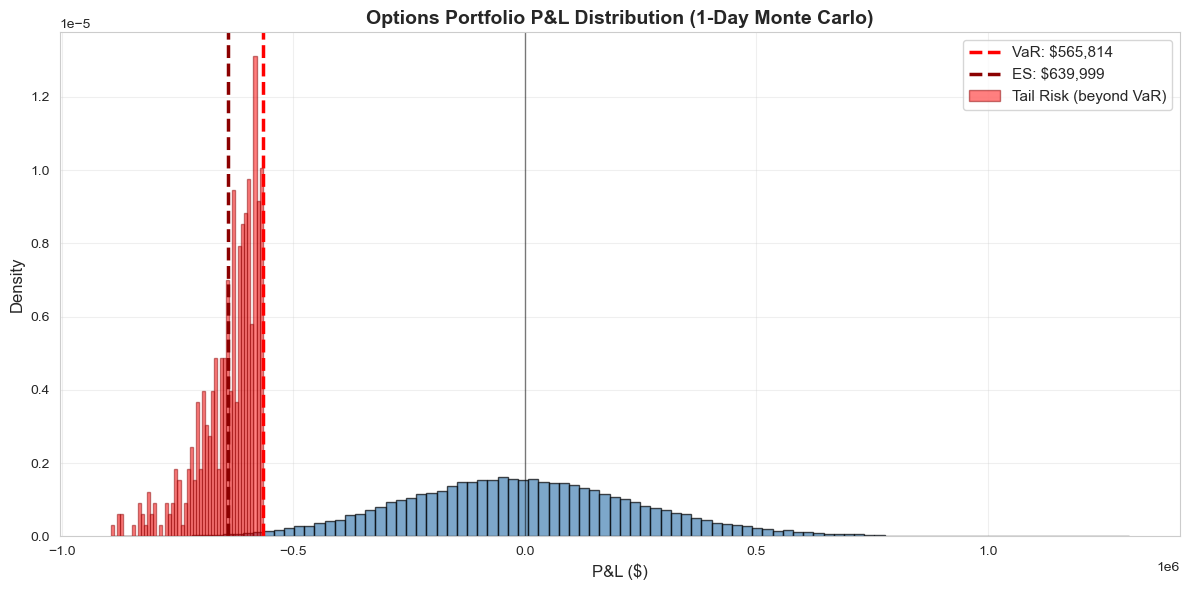

In [12]:
# Visualize P&L distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(portfolio_pnl, bins=100, alpha=0.7, density=True, 
        edgecolor='black', color='steelblue')
ax.axvline(-options_var, color='red', linestyle='--', linewidth=2.5, 
           label=f'VaR: ${options_var:,.0f}')
ax.axvline(-options_es, color='darkred', linestyle='--', linewidth=2.5, 
           label=f'ES: ${options_es:,.0f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Shade tail risk area
tail_values = portfolio_pnl[portfolio_pnl < -options_var]
if len(tail_values) > 0:
    ax.hist(tail_values, bins=50, alpha=0.5, color='red', 
            edgecolor='darkred', density=True, label='Tail Risk (beyond VaR)')

ax.set_title('Options Portfolio P&L Distribution (1-Day Monte Carlo)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('P&L ($)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()